# Fair Benchmark Review

This notebook follows a fairness-first framing for comparing CertCF against nominal baselines. The main comparison is **validity + proximity on the shared-success subset**. Unconditioned proximity is treated as diagnostic only.

## Setup

Load the benchmark parquet files manually and normalize method labels without relying on the notebook helper library.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from dataset_specs import get_tabular_dataset_spec

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)


In [2]:
RESULT_FILES = {
    "adult": Path("../results/benchmark_adult_meeting.parquet"),
    "compas": Path("../results/benchmark_compas_meeting.parquet"),
    "german_credit": Path("../results/benchmark_german_credit_meeting.parquet"),
    "heloc": Path("../results/benchmark_heloc_meeting.parquet"),
    "give_me_some_credit": Path("../results/benchmark_give_me_some_credit_meeting.parquet"),
    "lending_club": Path("../results/benchmark_lending_club_meeting.parquet"),
}

METHOD_ALIASES = {
    "certcf": "CertCF",
    "cpp": "CertCF",
    "CertCF": "CertCF",
    "CPP": "CertCF",
    "dice": "DiCE",
    "DiCE": "DiCE",
    "face": "FACE",
    "FACE": "FACE",
    "gs": "Growing Spheres",
    "growing_spheres": "Growing Spheres",
    "Growing Spheres": "Growing Spheres",
    "nn": "Nearest Neighbor",
    "nearest_neighbor": "Nearest Neighbor",
    "Nearest Neighbor": "Nearest Neighbor",
    "wachter": "Wachter",
    "Wachter": "Wachter",
}

METHOD_ORDER = ["CertCF", "DiCE", "FACE", "Growing Spheres", "Nearest Neighbor"]
SELECTED_METHODS = METHOD_ORDER.copy()


In [3]:
status_rows = []
frames = []

for dataset_name, rel_path in RESULT_FILES.items():
    resolved = rel_path if rel_path.is_absolute() else (Path.cwd() / rel_path).resolve()
    exists = resolved.exists()
    status_rows.append({
        "dataset": dataset_name,
        "requested_path": str(rel_path),
        "resolved_path": str(resolved),
        "available": exists,
    })
    if exists:
        dataset_df = pd.read_parquet(resolved).copy()
        dataset_df["dataset"] = dataset_name
        frames.append(dataset_df)

status_df = pd.DataFrame(status_rows)
display(status_df)

if not frames:
    raise RuntimeError("No benchmark parquet files were found.")

df = pd.concat(frames, ignore_index=True)
df["method_label"] = df["method"].map(METHOD_ALIASES).fillna(df["method"])
df = df[df["method_label"].isin(SELECTED_METHODS)].copy()

print(df.shape)
print(sorted(df["method_label"].dropna().unique().tolist()))


,dataset,requested_path,resolved_path,available
0,adult,../results/benchmark_adult_meeting.parquet,/home/gabrielepintus/Documents/github/Preimage...,True
1,compas,../results/benchmark_compas_meeting.parquet,/home/gabrielepintus/Documents/github/Preimage...,True
2,german_credit,../results/benchmark_german_credit_meeting.par...,/home/gabrielepintus/Documents/github/Preimage...,True
3,heloc,../results/benchmark_heloc_meeting.parquet,/home/gabrielepintus/Documents/github/Preimage...,True
4,give_me_some_credit,../results/benchmark_give_me_some_credit_meeti...,/home/gabrielepintus/Documents/github/Preimage...,True
5,lending_club,../results/benchmark_lending_club_meeting.parquet,/home/gabrielepintus/Documents/github/Preimage...,True


(1500, 225)
['CertCF', 'DiCE', 'FACE', 'Growing Spheres', 'Nearest Neighbor']


## Why The Main Comparison Must Be Conditioned

Average proximity computed on each method's own successful set is biased. Methods with lower coverage can look artificially good because they are evaluated only on easier tasks. The main comparison below therefore pairs:

1. **Validity / coverage**
2. **Proximity on the shared-success subset**

Everything else is treated as diagnostic evidence explaining the coverage/proximity tradeoff.

## Headline Table: Validity / Coverage

In [4]:
validity_summary = (
    df.groupby(["dataset", "method_label"])
    .agg(
        n_tasks=("success", "size"),
        n_valid=("success", "sum"),
        validity_pct=("success", lambda s: 100.0 * s.mean()),
    )
    .reset_index()
)

validity_table = validity_summary.pivot(index="method_label", columns="dataset", values="validity_pct")
validity_table = validity_table.reindex([m for m in METHOD_ORDER if m in validity_table.index])
validity_table.round(1)


dataset,adult,compas,german_credit,give_me_some_credit,heloc,lending_club
method_label,,,,,,
CertCF,100.0,100.0,100.0,46.0,100.0,100.0
DiCE,100.0,94.0,84.0,100.0,100.0,100.0
FACE,40.0,94.0,6.0,98.0,72.0,88.0
Growing Spheres,80.0,100.0,62.0,100.0,92.0,100.0
Nearest Neighbor,100.0,100.0,100.0,100.0,100.0,100.0


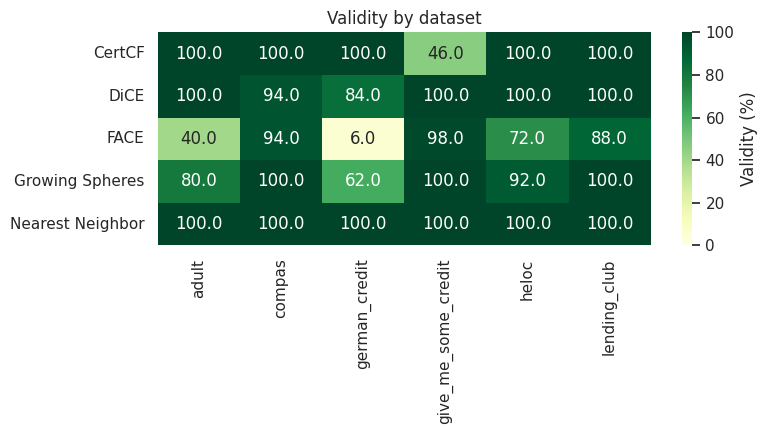

In [5]:
plt.figure(figsize=(8, 4.5))
sns.heatmap(validity_table, annot=True, fmt='.1f', cmap='YlGn', vmin=0, vmax=100, cbar_kws={"label": "Validity (%)"})
plt.title("Validity by dataset")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()


## Shared-Success Subset

Now keep only tasks where **all selected methods** succeeded on the same `(dataset, query_idx)` pair. This is the fairest subset for nominal proximity comparisons.

In [6]:
task_cols = ["dataset", "query_idx"]

shared_status = (
    df.groupby(task_cols + ["method_label"])["success"]
    .any()
    .unstack("method_label")
    .fillna(False)
)

shared_status = shared_status.reindex(columns=[m for m in SELECTED_METHODS if m in shared_status.columns])
shared_mask = shared_status.all(axis=1).rename("shared_success").reset_index()

retention = (
    shared_mask.groupby("dataset")
    .agg(
        n_total_tasks=("shared_success", "size"),
        n_shared_tasks=("shared_success", "sum"),
    )
)
retention["retention_pct"] = 100.0 * retention["n_shared_tasks"] / retention["n_total_tasks"]

display(retention.round(1))

shared_tasks = shared_mask[shared_mask["shared_success"]].drop(columns="shared_success")
df_shared = df.merge(shared_tasks, on=task_cols, how="inner")
df_shared = df_shared[df_shared["success"]].copy()

print(df_shared.shape)


,n_total_tasks,n_shared_tasks,retention_pct
dataset,,,
adult,50,19,38.0
compas,50,44,88.0
german_credit,50,0,0.0
give_me_some_credit,50,22,44.0
heloc,50,36,72.0
lending_club,50,44,88.0


(825, 225)


## Headline Table: Shared-Success Proximity

In [7]:
shared_l1 = df_shared.pivot_table(index="method_label", columns="dataset", values="l1_distance", aggfunc="mean")
shared_l2 = df_shared.pivot_table(index="method_label", columns="dataset", values="l2_distance", aggfunc="mean")
shared_l1 = shared_l1.reindex([m for m in METHOD_ORDER if m in shared_l1.index])
shared_l2 = shared_l2.reindex([m for m in METHOD_ORDER if m in shared_l2.index])

print("Mean L1 distance on shared-success subset")
display(shared_l1.round(3))
print("Mean L2 distance on shared-success subset")
display(shared_l2.round(3))


Mean L1 distance on shared-success subset


dataset,adult,compas,give_me_some_credit,heloc,lending_club
method_label,,,,,
CertCF,4.316,1.822,1.800,8.623,5.270
DiCE,1.350,2.237,1.939,4.143,5.441
FACE,5.561,2.016,3.033,9.840,6.592
Growing Spheres,0.709,1.071,1.212,2.679,1.731
Nearest Neighbor,4.246,0.969,1.705,6.830,3.543


Mean L2 distance on shared-success subset


dataset,adult,compas,give_me_some_credit,heloc,lending_club
method_label,,,,,
CertCF,1.927,1.118,0.893,2.480,2.160
DiCE,1.085,1.671,1.712,2.817,3.235
FACE,2.349,1.216,1.413,2.911,2.570
Growing Spheres,0.425,0.684,0.611,1.134,0.928
Nearest Neighbor,2.019,0.837,0.931,2.302,1.771


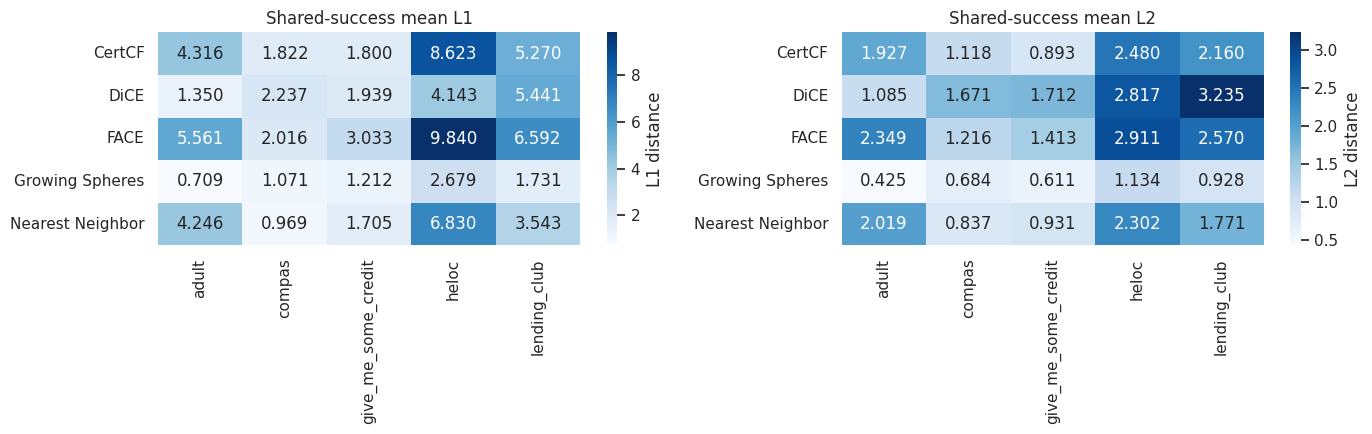

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.heatmap(shared_l1, annot=True, fmt='.3f', cmap='Blues', ax=axes[0], cbar_kws={"label": "L1 distance"})
axes[0].set_title("Shared-success mean L1")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

sns.heatmap(shared_l2, annot=True, fmt='.3f', cmap='Blues', ax=axes[1], cbar_kws={"label": "L2 distance"})
axes[1].set_title("Shared-success mean L2")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


## Diagnostic Only: Unconditioned Proximity

This table is **not** a fair headline comparison. It is shown only to visualize the size of the selection bias introduced by evaluating each method on its own successful set.

In [9]:
own_success = df[df["success"]].copy()
own_success_l1 = own_success.pivot_table(index="method_label", columns="dataset", values="l1_distance", aggfunc="mean")
own_success_l1 = own_success_l1.reindex([m for m in METHOD_ORDER if m in own_success_l1.index])
own_success_l1.round(3)


dataset,adult,compas,german_credit,give_me_some_credit,heloc,lending_club
method_label,,,,,,
CertCF,7.857,2.059,11.668,1.911,12.872,5.701
DiCE,1.832,2.227,7.492,1.993,5.615,5.382
FACE,6.090,2.008,12.414,3.212,9.840,6.592
Growing Spheres,1.118,1.114,2.173,1.195,2.728,1.748
Nearest Neighbor,7.887,1.144,10.487,1.726,10.353,3.706


## Diagnostic: CertCF Conditioned Proximity

These plots look only at **CertCF** distances and ask whether the same task was also solved by a competing method. This helps show whether higher CertCF distance comes from solving harder tasks that baselines miss.

In [10]:
method_status = (
    df[task_cols + ["method_label", "success"]]
    .drop_duplicates(subset=task_cols + ["method_label"])
    .copy()
)

certcf_rows = (
    df[(df["method_label"] == "CertCF") & df["success"] & df["l1_distance"].notna()]
    [task_cols + ["l1_distance"]]
    .rename(columns={"l1_distance": "certcf_l1_distance"})
    .copy()
)

comparison_rows = []
other_methods = [m for m in SELECTED_METHODS if m != "CertCF"]
for method_name in other_methods:
    other = method_status[method_status["method_label"] == method_name][task_cols + ["success"]].copy()
    other = other.rename(columns={"success": "other_success"})
    merged = certcf_rows.merge(other, on=task_cols, how="left")
    merged["other_method"] = method_name
    merged["other_success"] = merged["other_success"].fillna(False)
    merged["comparison_group"] = merged["other_success"].map({
        True: "Both succeeded",
        False: "CertCF only (other failed)",
    })
    comparison_rows.append(merged)

comparison_df = pd.concat(comparison_rows, ignore_index=True)
comparison_df.head()


,dataset,query_idx,certcf_l1_distance,other_success,other_method,comparison_group
0,adult,287,7.071299,True,DiCE,Both succeeded
1,adult,306,9.453877,True,DiCE,Both succeeded
2,adult,384,10.338592,True,DiCE,Both succeeded
3,adult,399,6.631077,True,DiCE,Both succeeded
4,adult,415,21.160835,True,DiCE,Both succeeded


In [11]:
conditioned_summary = (
    comparison_df.groupby(["dataset", "other_method", "comparison_group"])["certcf_l1_distance"]
    .agg(["count", "mean", "median", "std"])
    .sort_index()
)
conditioned_summary


count  \
dataset             other_method     comparison_group                    
adult               DiCE             Both succeeded                 50   
                    FACE             Both succeeded                 20   
                                     CertCF only (other failed)     30   
                    Growing Spheres  Both succeeded                 40   
                                     CertCF only (other failed)     10   
                    Nearest Neighbor Both succeeded                 50   
compas              DiCE             Both succeeded                 47   
                                     CertCF only (other failed)      3   
                    FACE             Both succeeded                 47   
                                     CertCF only (other failed)      3   
                    Growing Spheres  Both succeeded                 50   
                    Nearest Neighbor Both succeeded                 50   
german_credit       DiCE             Both succeeded                 42   
                                     CertCF only (other failed)      8   
                    FACE             Both succeeded                  3   
                                     CertCF only (other failed)     47   
                    Growing Spheres  Both succeeded                 31   
                                     CertCF only (other failed)     19   
                    Nearest Neighbor Both succeeded                 50   
give_me_some_credit DiCE             Both succeeded                 23   
                    FACE             Both succeeded                 22   
                                     CertCF only (other failed)      1   
                    Growing Spheres  Both succeeded                 23   
                    Nearest Neighbor Both succeeded                 23   
heloc               DiCE             Both succeeded                 50   
                    FACE             Both succeeded                 36   
                                     CertCF only (other failed)     14   
                    Growing Spheres  Both succeeded                 46   
                                     CertCF only (other failed)      4   
                    Nearest Neighbor Both succeeded                 50   
lending_club        DiCE             Both succeeded                 50   
                    FACE             Both succeeded                 44   
                                     CertCF only (other failed)      6   
                    Growing Spheres  Both succeeded                 50   
                    Nearest Neighbor Both succeeded                 50   

                                                                      mean  \
dataset             other_method     comparison_group                        
adult               DiCE             Both succeeded               7.857058   
                    FACE             Both succeeded               4.779964   
                                     CertCF only (other failed)   9.908454   
                    Growing Spheres  Both succeeded               7.107279   
                                     CertCF only (other failed)  10.856174   
                    Nearest Neighbor Both succeeded               7.857058   
compas              DiCE             Both succeeded               2.064642   
                                     CertCF only (other failed)   1.973179   
                    FACE             Both succeeded               1.831934   
                                     CertCF only (other failed)   5.618938   
                    Growing Spheres  Both succeeded               2.059154   
                    Nearest Neighbor Both succeeded               2.059154   
german_credit       DiCE             Both succeeded              11.336323   
                                     CertCF only (other failed)  13.408393   
                    FACE             Both succeeded              13.332567   


In [12]:
global_conditioned = (
    comparison_df.groupby(["other_method", "comparison_group"])["certcf_l1_distance"]
    .agg(["count", "mean", "median", "std"])
    .sort_index()
)
global_conditioned


count       mean     median  \
other_method     comparison_group                                          
DiCE             Both succeeded                262   7.399320   6.608957   
                 CertCF only (other failed)     11  10.289698  10.500782   
FACE             Both succeeded                172   4.672246   3.873704   
                 CertCF only (other failed)    101  12.358242  10.500782   
Growing Spheres  Both succeeded                240   6.098058   5.558478   
                 CertCF only (other failed)     33  17.826504  12.866991   
Nearest Neighbor Both succeeded                273   7.515783   6.707384   

                                                   std  
other_method     comparison_group                       
DiCE             Both succeeded               7.407554  
                 CertCF only (other failed)   6.694424  
FACE             Both succeeded               3.535446  
                 CertCF only (other failed)   9.466456  
Growing Spheres  Both succeeded               4.032450  
                 CertCF only (other failed)  14.770069  
Nearest Neighbor Both succeeded               7.390849

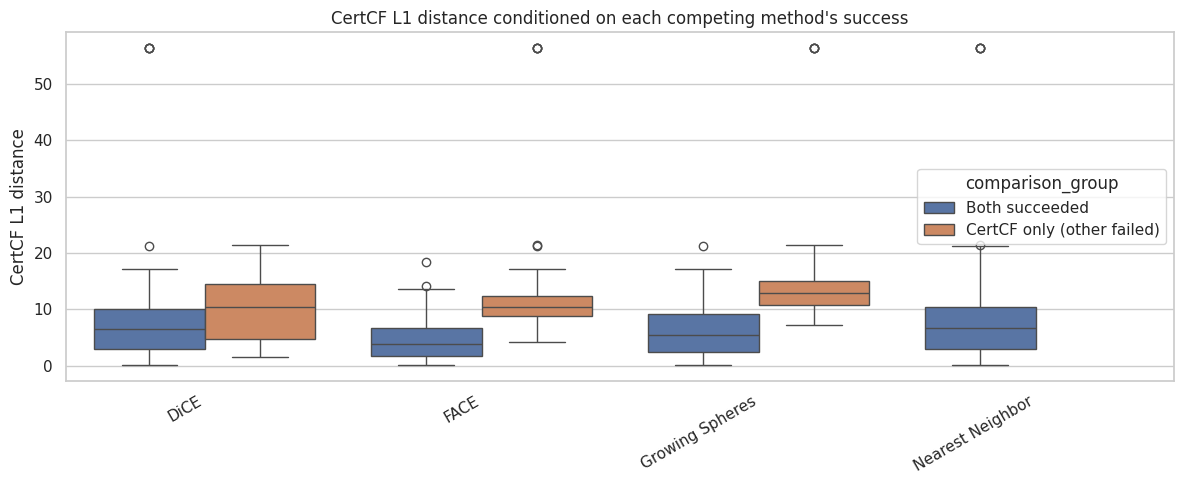

In [13]:
plt.figure(figsize=(12, 5))
sns.boxplot(
    data=comparison_df,
    x="other_method",
    y="certcf_l1_distance",
    hue="comparison_group",
    hue_order=["Both succeeded", "CertCF only (other failed)"],
)
plt.xticks(rotation=30, ha="right")
plt.title("CertCF L1 distance conditioned on each competing method's success")
plt.xlabel("")
plt.ylabel("CertCF L1 distance")
plt.tight_layout()
plt.show()


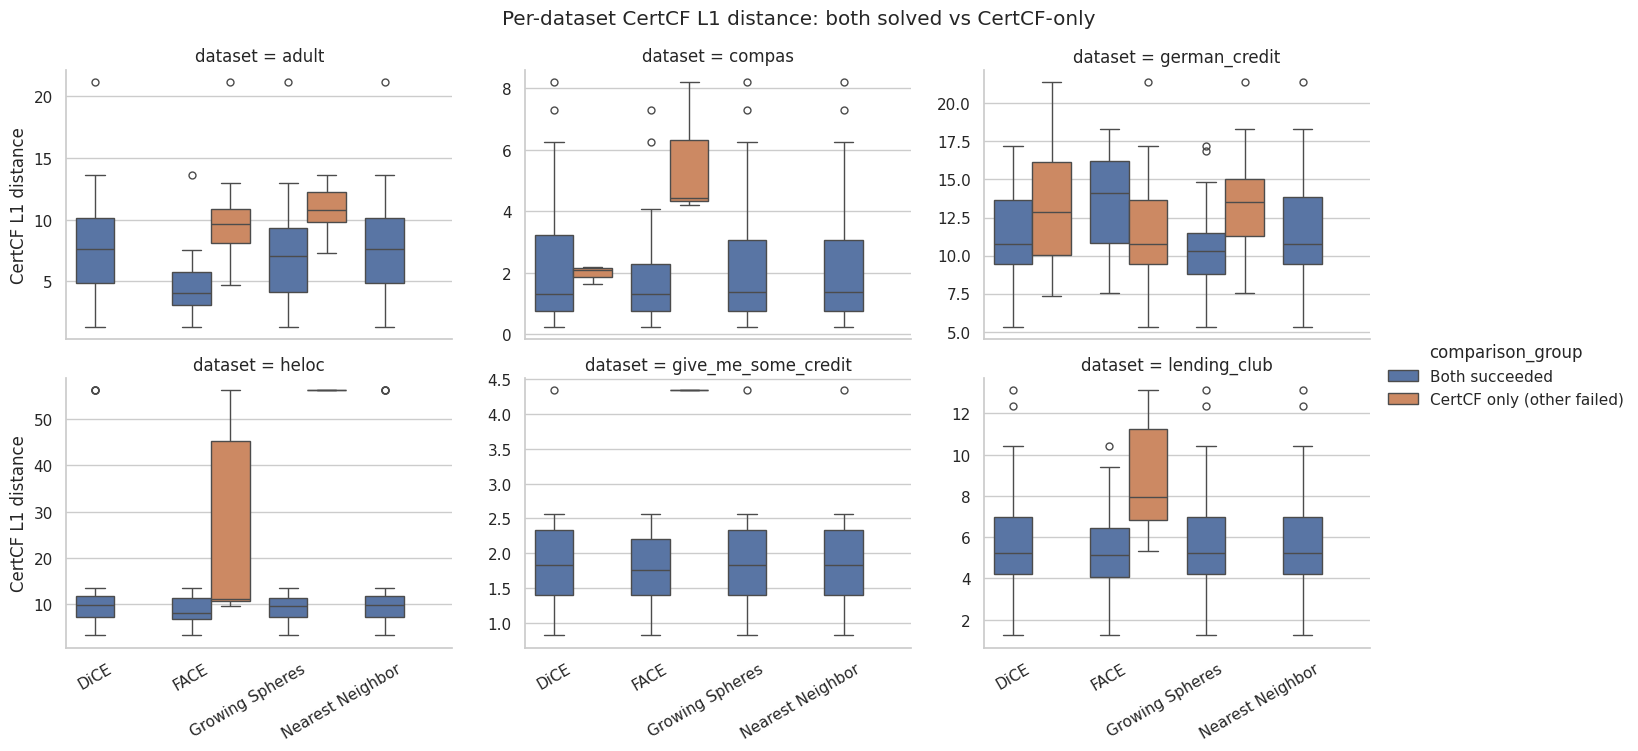

In [14]:
g = sns.catplot(
    data=comparison_df,
    x="other_method",
    y="certcf_l1_distance",
    hue="comparison_group",
    hue_order=["Both succeeded", "CertCF only (other failed)"],
    col="dataset",
    kind="box",
    col_wrap=3,
    sharey=False,
    height=3.8,
    aspect=1.25,
)

n_cols = 3
n_axes = len(g.axes.flat)
n_rows = (n_axes + n_cols - 1) // n_cols
bottom_start = (n_rows - 1) * n_cols

for idx, ax in enumerate(g.axes.flat):
    is_bottom_row = idx >= bottom_start
    ax.tick_params(axis="x", labelbottom=is_bottom_row)
    if is_bottom_row:
        plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

g.set_axis_labels("", "CertCF L1 distance")
g.fig.subplots_adjust(top=0.9, bottom=0.14)
g.fig.suptitle("Per-dataset CertCF L1 distance: both solved vs CertCF-only")
plt.show()


## Adult Diagnostic: Feature-Change Pattern

This final section checks whether methods rely on very narrow feature-edit patterns on Adult. It is useful for understanding suspiciously low-distance baselines such as Growing Spheres.

In [15]:
adult_df = df[(df["dataset"] == "adult") & (df["success"])].copy()
spec = get_tabular_dataset_spec("adult")

x_orig_cols = sorted([c for c in adult_df.columns if c.startswith("x_orig_")], key=lambda c: int(c.split("_")[-1]))
x_cf_cols = sorted([c for c in adult_df.columns if c.startswith("x_cf_")], key=lambda c: int(c.split("_")[-1]))

rows = []
for method_name, method_df in adult_df.groupby("method_label", sort=False):
    x_orig = method_df[x_orig_cols].to_numpy(dtype=float)
    x_cf = method_df[x_cf_cols].to_numpy(dtype=float)

    for feature_name, (start, end) in zip(spec.feature_names, spec.feature_slices):
        changed = (abs(x_cf[:, start:end] - x_orig[:, start:end]) > 1e-6).any(axis=1)
        rows.append({
            "method_label": method_name,
            "feature": feature_name,
            "change_rate_pct": 100.0 * changed.mean(),
        })

adult_feature_change = pd.DataFrame(rows)
adult_feature_change_pivot = adult_feature_change.pivot(index="feature", columns="method_label", values="change_rate_pct")
adult_feature_change_pivot = adult_feature_change_pivot.reindex(columns=[m for m in METHOD_ORDER if m in adult_feature_change_pivot.columns])
adult_feature_change_pivot.round(1)


method_label,CertCF,DiCE,FACE,Growing Spheres,Nearest Neighbor
feature,,,,,
age,98.0,2.0,95.0,60.0,100.0
capital-gain,30.0,100.0,15.0,100.0,8.0
capital-loss,10.0,100.0,0.0,20.0,8.0
education,40.0,6.0,55.0,0.0,36.0
education-num,48.0,0.0,55.0,42.5,36.0
fnlwgt,100.0,18.0,100.0,5.0,100.0
hours-per-week,54.0,2.0,35.0,45.0,56.0
marital-status,54.0,0.0,0.0,0.0,54.0
native-country,14.0,6.0,20.0,0.0,14.0


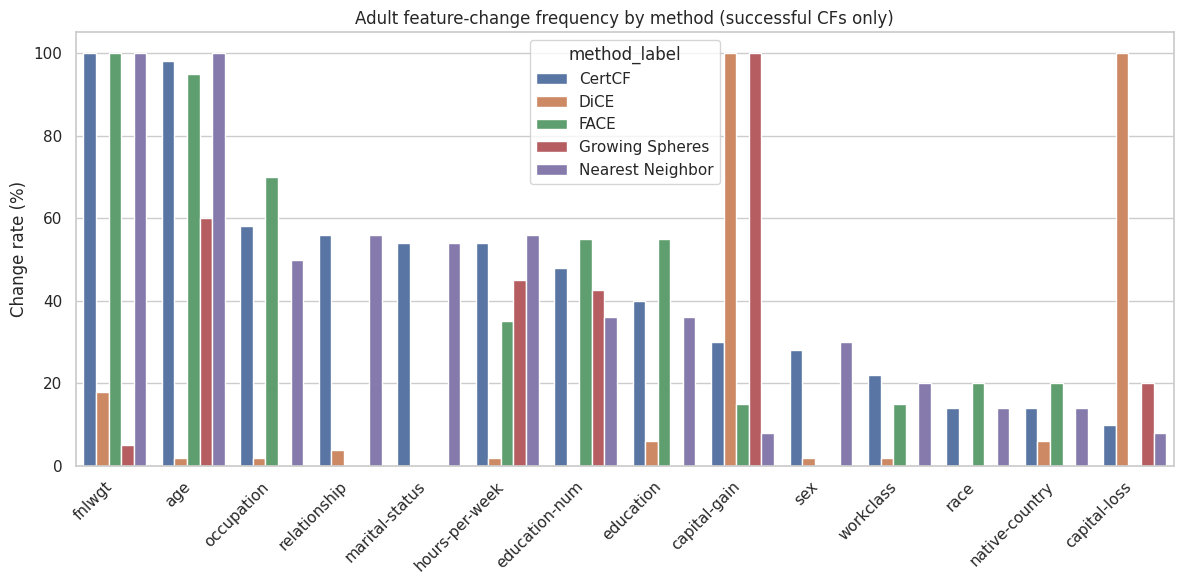

In [16]:
plot_df = adult_feature_change.copy()
plot_df = plot_df.sort_values(["method_label", "change_rate_pct"], ascending=[True, False])

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="feature", y="change_rate_pct", hue="method_label")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Change rate (%)")
plt.xlabel("")
plt.title("Adult feature-change frequency by method (successful CFs only)")
plt.tight_layout()
plt.show()
